In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
test = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")


In [3]:
print(train.head())
print(test.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
  

In [4]:
print(train.columns)
print(test.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')


In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain info:")
print(train.info())

print("\nMissing values in train:")
print(train.isnull().sum())

print("\nTarget distribution:")
print(train["Transported"].value_counts())
print(train["Transported"].value_counts(normalize=True))

Train shape: (8693, 14)
Test shape: (4277, 13)

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

Missing values in train:
PassengerId       0
HomePlanet      201
CryoSleep  

In [6]:
y = train["Transported"]
y.mean()

np.float64(0.5036236051995858)

In [7]:
train.isnull().mean().sort_values(ascending = False)

CryoSleep       0.024963
ShoppingMall    0.023927
VIP             0.023352
HomePlanet      0.023122
Name            0.023007
Cabin           0.022892
VRDeck          0.021627
Spa             0.021051
FoodCourt       0.021051
Destination     0.020936
RoomService     0.020821
Age             0.020591
PassengerId     0.000000
Transported     0.000000
dtype: float64

In [8]:
train.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

In [9]:
train = train.drop(columns=["Name"])
test = test.drop(columns=["Name"])

In [10]:
print(train["PassengerId"].head(10))
print(train["PassengerId"].nunique())
print(train["PassengerId"].str.split("_").head())

0    0001_01
1    0002_01
2    0003_01
3    0003_02
4    0004_01
5    0005_01
6    0006_01
7    0006_02
8    0007_01
9    0008_01
Name: PassengerId, dtype: object
8693
0    [0001, 01]
1    [0002, 01]
2    [0003, 01]
3    [0003, 02]
4    [0004, 01]
Name: PassengerId, dtype: object


In [11]:
train["Group"] = train["PassengerId"].str.split("_").str[0]
test["Group"] = test["PassengerId"].str.split("_").str[0]

train["GroupSize"] = train.groupby("Group")["Group"].transform("count")
test["GroupSize"] = test.groupby("Group")["Group"].transform("count")

print(train[["PassengerId", "Group", "GroupSize"]].head(10))

  PassengerId Group  GroupSize
0     0001_01  0001          1
1     0002_01  0002          1
2     0003_01  0003          2
3     0003_02  0003          2
4     0004_01  0004          1
5     0005_01  0005          1
6     0006_01  0006          2
7     0006_02  0006          2
8     0007_01  0007          1
9     0008_01  0008          3


In [12]:
train.groupby("GroupSize")["Transported"].mean()

GroupSize
1    0.452445
2    0.538050
3    0.593137
4    0.640777
5    0.592453
6    0.614943
7    0.541126
8    0.394231
Name: Transported, dtype: float64

In [13]:
# Drop Group and PassengerId column to avoid high-cardinality feature that may cause overfitting
train.drop(columns=["Group"], inplace=True)
test.drop(columns=["Group"], inplace=True)
train = train.drop(columns=["PassengerId"])
test = test.drop(columns=["PassengerId"])

In [14]:
train.columns

Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'GroupSize'],
      dtype='object')

In [15]:
print(train["HomePlanet"].head())
print(train["HomePlanet"].value_counts(dropna=False))
print("\nTransport rate per planet:")
print(train.groupby("HomePlanet")["Transported"].mean())

0    Europa
1     Earth
2    Europa
3    Europa
4     Earth
Name: HomePlanet, dtype: object
HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64

Transport rate per planet:
HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64


In [16]:
# Fill missing HomePlanet with new category "Unknown"
train["HomePlanet"] = train["HomePlanet"].fillna("Unknown")
test["HomePlanet"] = test["HomePlanet"].fillna("Unknown")
print(train["HomePlanet"].value_counts())

HomePlanet
Earth      4602
Europa     2131
Mars       1759
Unknown     201
Name: count, dtype: int64


In [17]:
# One-hot encode HomePlanet
# One-hot encode HomePlanet
train = pd.get_dummies(train, columns=["HomePlanet"], drop_first=False)
test = pd.get_dummies(test, columns=["HomePlanet"], drop_first=False)


In [18]:
train.filter(like="HomePlanet").head()

,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_Unknown
0,False,True,False,False
1,True,False,False,False
2,False,True,False,False
3,False,True,False,False
4,True,False,False,False


In [19]:
homeplanet_cols = [col for col in train.columns if "HomePlanet_" in col]

train[homeplanet_cols] = train[homeplanet_cols].astype(int)
test[homeplanet_cols] = test[homeplanet_cols].astype(int)

In [20]:
train[homeplanet_cols].head()

,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_Unknown
0,0,1,0,0
1,1,0,0,0
2,0,1,0,0
3,0,1,0,0
4,1,0,0,0


In [21]:
print(train["CryoSleep"].head())
print(train["CryoSleep"].value_counts(dropna=False))
print("\nTransport rate:")
print(train.groupby("CryoSleep")["Transported"].mean())

0    False
1    False
2    False
3    False
4    False
Name: CryoSleep, dtype: object
CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64

Transport rate:
CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64


In [22]:
# Create total spending feature
spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

train["TotalSpending"] = train[spending_cols].sum(axis=1)
test["TotalSpending"] = test[spending_cols].sum(axis=1)

print(train[["TotalSpending", "CryoSleep"]].head(10))

   TotalSpending CryoSleep
0            0.0     False
1          736.0     False
2        10383.0     False
3         5176.0     False
4         1091.0     False
5          774.0     False
6         1584.0     False
7            0.0      True
8         1018.0     False
9            0.0      True


In [23]:
# Case 1: Not in CryoSleep but spent nothing
case1 = train[(train["CryoSleep"] == False) & (train["TotalSpending"] == 0)]
print("False & zero spending:", len(case1))

# Case 2: In CryoSleep but spent money (logic violation)
case2 = train[(train["CryoSleep"] == True) & (train["TotalSpending"] > 0)]
print("True & positive spending:", len(case2))

False & zero spending: 518
True & positive spending: 0


In [24]:
zero_spend = train[train["TotalSpending"] == 0]
print(zero_spend["CryoSleep"].value_counts(normalize=True))

CryoSleep
True     0.85429
False    0.14571
Name: proportion, dtype: float64


In [25]:
# Fill CryoSleep based on TotalSpending

# If spending > 0 → not in CryoSleep
train.loc[(train["CryoSleep"].isna()) & (train["TotalSpending"] > 0), "CryoSleep"] = False
test.loc[(test["CryoSleep"].isna()) & (test["TotalSpending"] > 0), "CryoSleep"] = False

# If spending == 0 → assume CryoSleep
train.loc[(train["CryoSleep"].isna()) & (train["TotalSpending"] == 0), "CryoSleep"] = True
test.loc[(test["CryoSleep"].isna()) & (test["TotalSpending"] == 0), "CryoSleep"] = True

In [26]:
train["CryoSleep"].isna().sum()

np.int64(0)

In [27]:
train["CryoSleep"] = train["CryoSleep"].astype(int)
test["CryoSleep"] = test["CryoSleep"].astype(int)

In [28]:
train["CryoSleep"].dtype

dtype('int64')

In [29]:
train[["Deck", "CabinNum", "Side"]] = train["Cabin"].str.split("/", expand=True)
test[["Deck", "CabinNum", "Side"]] = test["Cabin"].str.split("/", expand=True)

In [30]:
train[["Deck", "CabinNum", "Side"]].head()

,Deck,CabinNum,Side
0,B,0,P
1,F,0,S
2,A,0,S
3,A,0,S
4,F,1,S


In [31]:
print(train["Deck"].value_counts())
print(train["CabinNum"].value_counts())
train["Side"].value_counts()

Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64
CabinNum
82      28
86      22
19      22
176     21
56      21
        ..
1839     1
1848     1
1847     1
1749     1
1782     1
Name: count, Length: 1817, dtype: int64


Side
S    4288
P    4206
Name: count, dtype: int64

In [32]:
train[["Deck", "Side"]].isna().sum()

Deck    199
Side    199
dtype: int64

In [33]:
train["Deck"] = train["Deck"].fillna("Unknown")
test["Deck"] = test["Deck"].fillna("Unknown")

train["Side"] = train["Side"].fillna("Unknown")
test["Side"] = test["Side"].fillna("Unknown")

In [34]:
train[["Deck", "Side"]].isna().sum()

Deck    0
Side    0
dtype: int64

In [35]:
train = pd.get_dummies(train, columns=["Deck", "Side"], drop_first=True)
test = pd.get_dummies(test, columns=["Deck", "Side"], drop_first=True)

In [36]:
train, test = train.align(test, join="left", axis=1, fill_value=0)

In [37]:
print(train.shape)
print(test.shape)

(8693, 28)
(4277, 28)


In [38]:
train = train.drop(columns=["Cabin"])
test = test.drop(columns=["Cabin"])
train = train.drop(columns=["CabinNum"])
test = test.drop(columns=["CabinNum"])

In [39]:
print(train["Destination"].head())
print(train["Destination"].value_counts(dropna=False))
print(train.groupby("Destination")["Transported"].mean())

0    TRAPPIST-1e
1    TRAPPIST-1e
2    TRAPPIST-1e
3    TRAPPIST-1e
4    TRAPPIST-1e
Name: Destination, dtype: object
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64
Destination
55 Cancri e      0.610000
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64


In [40]:
train["Destination"] = train["Destination"].fillna("Unknown")
test["Destination"] = test["Destination"].fillna("Unknown")

In [41]:
train["Destination"].isna().sum()

np.int64(0)

In [42]:
train = pd.get_dummies(train, columns=["Destination"], drop_first=True)
test = pd.get_dummies(test, columns=["Destination"], drop_first=True)

In [43]:
train, test = train.align(test, join="left", axis=1, fill_value=0)

In [44]:
print(train.shape)
print(test.shape)

(8693, 28)
(4277, 28)


In [45]:
print(train["VIP"].head())
print(train["VIP"].value_counts(dropna=False))
print(train.groupby("VIP")["Transported"].mean())

0    False
1    False
2     True
3    False
4    False
Name: VIP, dtype: object
VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64
VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64


In [46]:
train["VIP"] = train["VIP"].fillna(False).astype(bool)
test["VIP"] = test["VIP"].fillna(False).astype(bool)

/tmp/ipykernel_17/156884378.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train["VIP"] = train["VIP"].fillna(False).astype(bool)
/tmp/ipykernel_17/156884378.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test["VIP"] = test["VIP"].fillna(False).astype(bool)


In [47]:
train["VIP"] = train["VIP"].astype(int)
test["VIP"] = test["VIP"].astype(int)

In [48]:
train["VIP"].value_counts()

VIP
0    8494
1     199
Name: count, dtype: int64

In [49]:
train["Age"].describe()

count    8514.000000
mean       28.827930
std        14.489021
min         0.000000
25%        19.000000
50%        27.000000
75%        38.000000
max        79.000000
Name: Age, dtype: float64

In [50]:
train.groupby(pd.cut(train["Age"], bins=5))["Transported"].mean()

/tmp/ipykernel_17/4278156953.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby(pd.cut(train["Age"], bins=5))["Transported"].mean()


Age
(-0.079, 15.8]    0.648387
(15.8, 31.6]      0.474293
(31.6, 47.4]      0.485510
(47.4, 63.2]      0.486747
(63.2, 79.0]      0.463235
Name: Transported, dtype: float64

In [51]:
int(train["Age"].isna().sum())

179

In [52]:
median_age = train["Age"].median()
train["Age"] = train["Age"].fillna(median_age)
test["Age"] = train["Age"].fillna(median_age)
int(train["Age"].isna().sum())

0

In [53]:
train["IsChild"] = (train["Age"] < 16).astype(int)
test["IsChild"] = (test["Age"] < 16).astype(int)

In [54]:
train["IsChild"].value_counts()

IsChild
0    7453
1    1240
Name: count, dtype: int64

In [55]:
train.groupby("IsChild")["Transported"].mean()

IsChild
0    0.479538
1    0.648387
Name: Transported, dtype: float64

In [56]:
train.columns

Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Transported', 'GroupSize', 'HomePlanet_Earth',
       'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_Unknown',
       'TotalSpending', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F',
       'Deck_G', 'Deck_T', 'Deck_Unknown', 'Side_S', 'Side_Unknown',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e',
       'Destination_Unknown', 'IsChild'],
      dtype='object')

In [57]:
train[["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]].isna().sum()

RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
dtype: int64

In [58]:
spending_cols = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]

train[spending_cols] = train[spending_cols].fillna(0)
test[spending_cols] = test[spending_cols].fillna(0)

In [59]:
train[spending_cols].isna().sum()

RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

In [60]:
train["TotalSpending"].describe()

count     8693.000000
mean      1440.866329
std       2803.045694
min          0.000000
25%          0.000000
50%        716.000000
75%       1441.000000
max      35987.000000
Name: TotalSpending, dtype: float64

In [61]:
print(train["TotalSpending"].skew())

4.417588190022683


In [62]:
train.select_dtypes(include=["int64","float64"]).skew().sort_values(ascending=False)

ShoppingMall          12.763842
VRDeck                 7.904554
Spa                    7.716450
FoodCourt              7.177515
RoomService            6.397766
VIP                    6.381293
HomePlanet_Unknown     6.347151
TotalSpending          4.417588
IsChild                2.044089
GroupSize              1.889017
HomePlanet_Mars        1.482042
HomePlanet_Europa      1.185132
CryoSleep              0.580564
Age                    0.431102
HomePlanet_Earth      -0.117790
dtype: float64

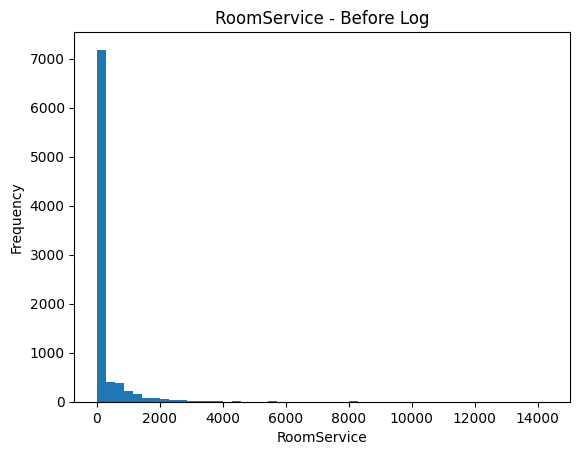

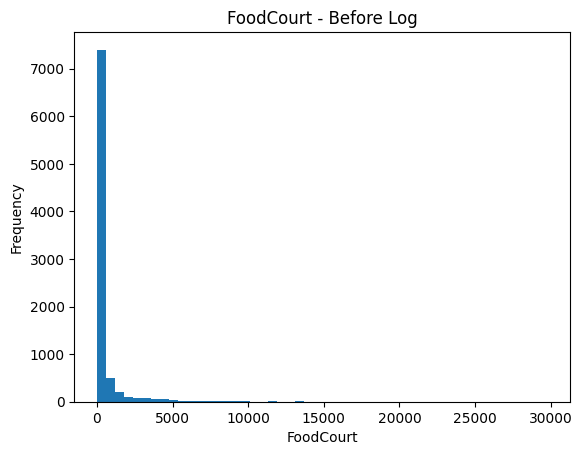

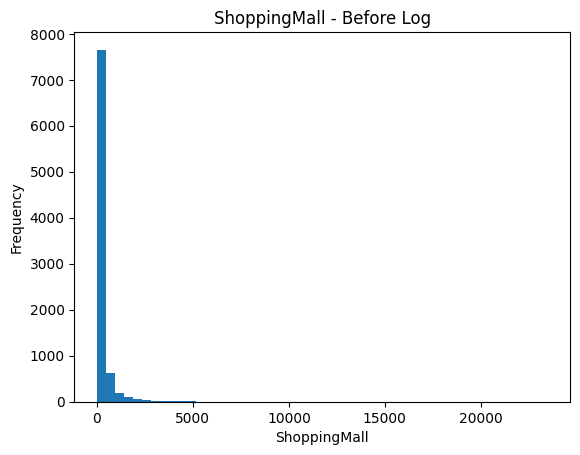

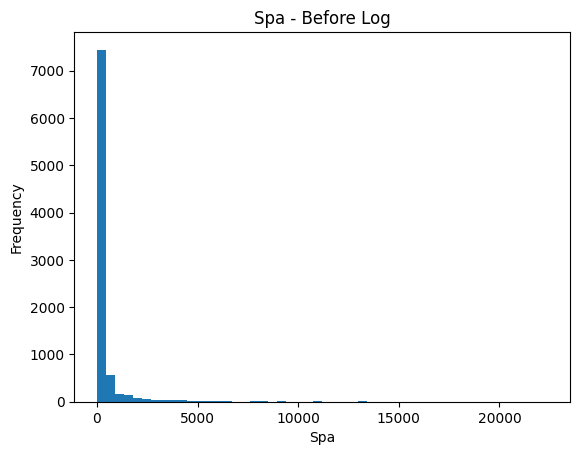

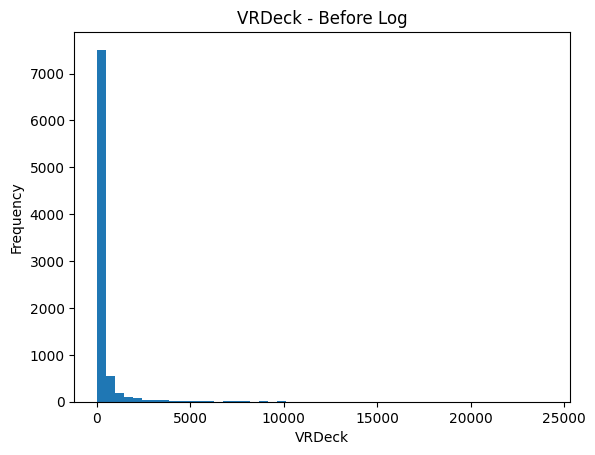

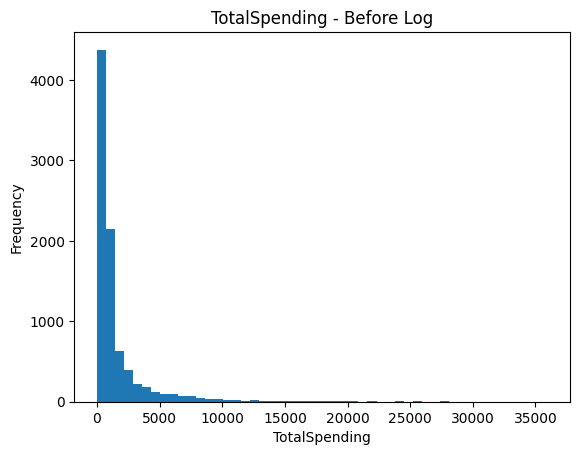

In [63]:
import matplotlib.pyplot as plt

spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
    "TotalSpending"
]

for col in spending_cols:
    plt.figure()
    plt.hist(train[col], bins=50)
    plt.title(f"{col} - Before Log")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [64]:
for col in spending_cols:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

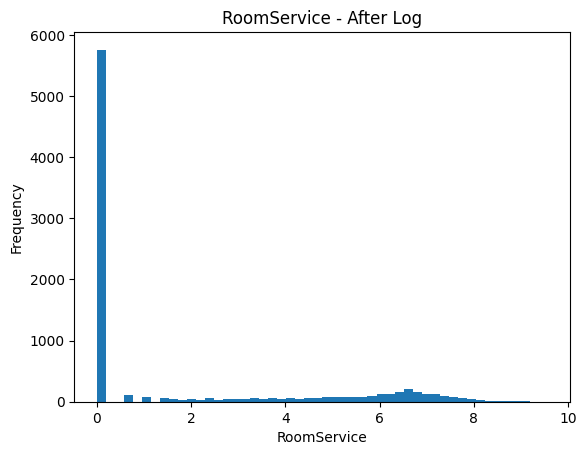

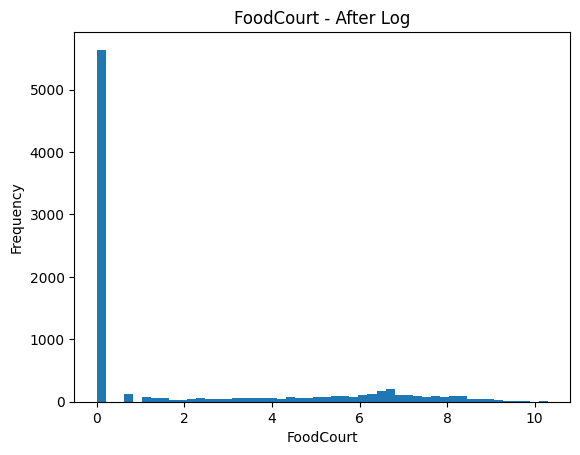

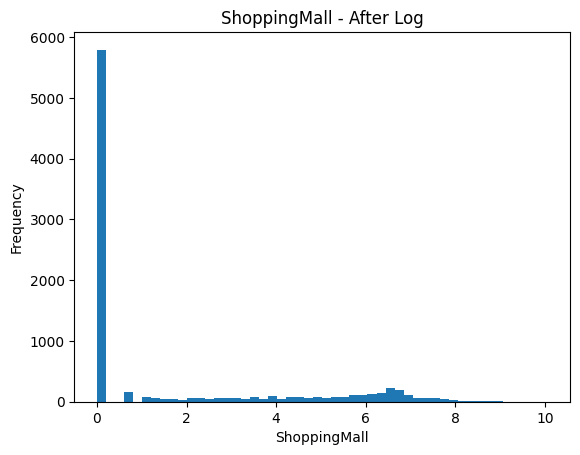

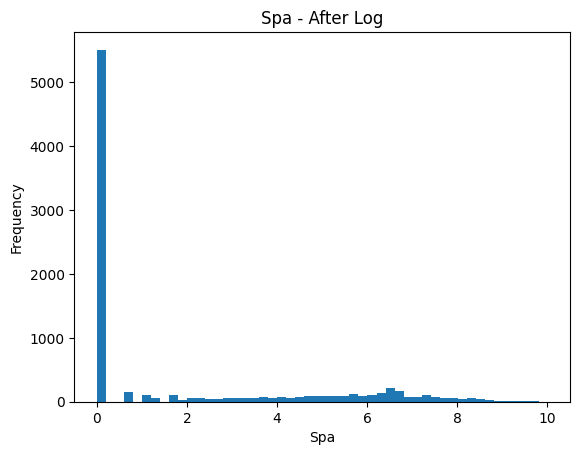

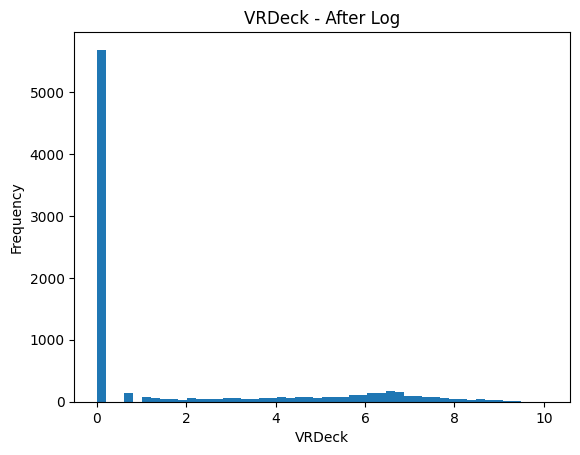

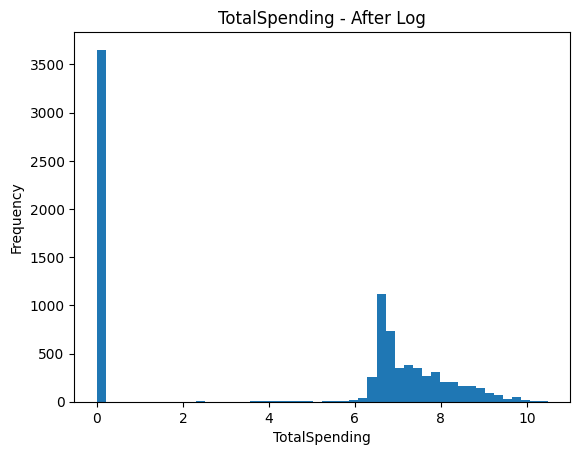

In [65]:
for col in spending_cols:
    plt.figure()
    plt.hist(train[col], bins=50)
    plt.title(f"{col} - After Log")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [66]:
train[spending_cols].skew().sort_values(ascending=False)

ShoppingMall     1.238498
VRDeck           1.193417
RoomService      1.149866
FoodCourt        1.143177
Spa              1.122324
TotalSpending   -0.212435
dtype: float64

In [67]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [68]:
test = test.drop(columns=["Transported"])

In [69]:
test.dtypes

CryoSleep                      int64
Age                          float64
VIP                            int64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
GroupSize                      int64
HomePlanet_Earth               int64
HomePlanet_Europa              int64
HomePlanet_Mars                int64
HomePlanet_Unknown             int64
TotalSpending                float64
Deck_B                          bool
Deck_C                          bool
Deck_D                          bool
Deck_E                          bool
Deck_F                          bool
Deck_G                          bool
Deck_T                          bool
Deck_Unknown                    bool
Side_S                          bool
Side_Unknown                    bool
Destination_PSO J318.5-22       bool
Destination_TRAPPIST-1e         bool
Destination_Unknown             bool
I

In [70]:
X = train.drop("Transported", axis=1)
y = train["Transported"]

In [71]:
print("X shape:", X.shape)
print("Test shape:", test.shape)

X shape: (8693, 28)
Test shape: (4277, 28)


In [72]:
X.dtypes

CryoSleep                      int64
Age                          float64
VIP                            int64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
GroupSize                      int64
HomePlanet_Earth               int64
HomePlanet_Europa              int64
HomePlanet_Mars                int64
HomePlanet_Unknown             int64
TotalSpending                float64
Deck_B                          bool
Deck_C                          bool
Deck_D                          bool
Deck_E                          bool
Deck_F                          bool
Deck_G                          bool
Deck_T                          bool
Deck_Unknown                    bool
Side_S                          bool
Side_Unknown                    bool
Destination_PSO J318.5-22       bool
Destination_TRAPPIST-1e         bool
Destination_Unknown             bool
I

In [73]:
print("Missing values in X:")
print(X.isna().sum().sort_values(ascending=False))

Missing values in X:
CryoSleep                    0
Age                          0
VIP                          0
RoomService                  0
FoodCourt                    0
ShoppingMall                 0
Spa                          0
VRDeck                       0
GroupSize                    0
HomePlanet_Earth             0
HomePlanet_Europa            0
HomePlanet_Mars              0
HomePlanet_Unknown           0
TotalSpending                0
Deck_B                       0
Deck_C                       0
Deck_D                       0
Deck_E                       0
Deck_F                       0
Deck_G                       0
Deck_T                       0
Deck_Unknown                 0
Side_S                       0
Side_Unknown                 0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
Destination_Unknown          0
IsChild                      0
dtype: int64


In [74]:

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="lbfgs"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "Linear SVC": SVC(
        kernel="linear",
        C=1.0
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

results = {}

print("Running model benchmark...\n")

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

results_df = (
    pd.DataFrame(results.items(), columns=["Model", "CV Accuracy"])
    .sort_values(by="CV Accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nSorted Results:")
print(results_df)

Running model benchmark...

Logistic Regression: 0.7722
Random Forest: 0.7867
Extra Trees: 0.7733
Gradient Boosting: 0.7997
AdaBoost: 0.7542
KNN: 0.7546
Linear SVC: 0.7733
XGBoost: 0.8038

Sorted Results:
                 Model  CV Accuracy
0              XGBoost     0.803752
1    Gradient Boosting     0.799727
2        Random Forest     0.786726
3           Linear SVC     0.773268
4          Extra Trees     0.773267
5  Logistic Regression     0.772231
6                  KNN     0.754632
7             AdaBoost     0.754173


In [75]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.015,
    max_depth=5,
    min_child_weight=3,
    gamma=0,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy", n_jobs=-1)

print("Best CV Score:", scores.mean())
print("Fold Scores:", scores)
best_model.fit(X, y)

Best CV Score: 0.8068558507825946
Fold Scores: [0.81368603 0.80276021 0.80621047 0.82623705 0.7853855 ]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.015, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [76]:
original_test_df = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")

In [77]:
preds = best_model.predict(test)

In [78]:
# Convert to boolean (VERY IMPORTANT)
preds = preds.astype(bool)

# Create submission using ORIGINAL test file
submission = pd.DataFrame({
    "PassengerId": original_test_df["PassengerId"],
    "Transported": preds
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
submission.dtypes

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True


PassengerId    object
Transported      bool
dtype: object